# Proyek Akhir: Menyelesaikan Permasalahan Institusi Pendidikan

- Nama: Putu Mahdalika Intan Pratiwi
- Email: mahdaalikaputu@gmail.com
- ID Dicoding: M014D5X1587

## Persiapan

**Bussiness Understanding**

Berdasarkan kebutuhan pengguna (pihak institusi), terdapat beberapa pertanyaan bisnis yang ingin dijawab melalui analisis data sebagai berikut:
1. Apakah performa akademik siswa memengaruhi kemungkinan dropout?
2. Apakah faktor finansial seperti status pembayaran dan beasiswa berpengaruh terhadap dropout?
3. Apakah faktor demografi seperti gender dan latar belakang memengaruhi keberhasilan studi?
4. Faktor apa yang paling berpengaruh dalam menentukan siswa akan dropout atau graduate?
5. Seberapa akurat model Machine Learning dalam memprediksi status siswa?


**Menentukan Cakupan Proyek**

Untuk menjawab permasalahan tersebut, akan dilakukan analisis data dan pengembangan model prediksi menggunakan metode Machine Learning. Proyek ini akan mencakup beberapa pendekatan utama, seperti Exploratory Data Analysis (EDA) untuk memperoleh gambaran terkait dataset yang akan digunakan, pembuatan dashboard, serta pembangunan model klasifikasi untuk memprediksi status siswa.

Pendekatan Machine Learning yang akan digunakan disesuaikan dengan karakteristik dataset, dengan melakukan perbandingan beberapa algoritma untuk mendapatkan performa terbaik.

Berdasarkan cakupan proyek tersebut, dibutuhkan beberapa resource dan tool, yaitu

- Data performa siswa (Students' Performance Dataset)
- Bahasa pemrograman Python sebagai tool utama dalam proyek ini
- Serta, berbagai library pendukung untuk pengolahan data dan pengembangan model machine learning.
- Tools visualisasi seperti Metabase untuk dashboard
- Streamlit untuk deployment model prediksi

### Menyiapkan library yang dibutuhkan

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report

### Menyiapkan data yang akan diguankan

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# Load data
students_df = pd.read_csv(
    "/content/drive/MyDrive/Submission Pertama Data Scientist/Submission Akhir/data.csv", sep= ';', encoding='utf-8'
)

## Data Understanding

In [4]:
# Menampilkan 5 baris pertama
students_df.head()

,Marital_status,Application_mode,Application_order,Course,Daytime_evening_attendance,Previous_qualification,Previous_qualification_grade,Nacionality,Mothers_qualification,Fathers_qualification,...,Curricular_units_2nd_sem_credited,Curricular_units_2nd_sem_enrolled,Curricular_units_2nd_sem_evaluations,Curricular_units_2nd_sem_approved,Curricular_units_2nd_sem_grade,Curricular_units_2nd_sem_without_evaluations,Unemployment_rate,Inflation_rate,GDP,Status
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


In [5]:
# Tinjau jumlah baris kolom dan jenis data dalam dataset dengan info
students_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 37 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   Marital_status                                4424 non-null   int64  
 1   Application_mode                              4424 non-null   int64  
 2   Application_order                             4424 non-null   int64  
 3   Course                                        4424 non-null   int64  
 4   Daytime_evening_attendance                    4424 non-null   int64  
 5   Previous_qualification                        4424 non-null   int64  
 6   Previous_qualification_grade                  4424 non-null   float64
 7   Nacionality                                   4424 non-null   int64  
 8   Mothers_qualification                         4424 non-null   int64  
 9   Fathers_qualification                         4424 non-null   i

In [6]:
# Menampilkan statistik deskriptif dataset
students_df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Marital_status,4424.0,NaN,NaN,NaN,1.178571,0.605747,1.0,1.0,1.0,1.0,6.0
Application_mode,4424.0,NaN,NaN,NaN,18.669078,17.484682,1.0,1.0,17.0,39.0,57.0
Application_order,4424.0,NaN,NaN,NaN,1.727848,1.313793,0.0,1.0,1.0,2.0,9.0
Course,4424.0,NaN,NaN,NaN,8856.642631,2063.566416,33.0,9085.0,9238.0,9556.0,9991.0
Daytime_evening_attendance,4424.0,NaN,NaN,NaN,0.890823,0.311897,0.0,1.0,1.0,1.0,1.0
Previous_qualification,4424.0,NaN,NaN,NaN,4.577758,10.216592,1.0,1.0,1.0,1.0,43.0
Previous_qualification_grade,4424.0,NaN,NaN,NaN,132.613314,13.188332,95.0,125.0,133.1,140.0,190.0
Nacionality,4424.0,NaN,NaN,NaN,1.873192,6.914514,1.0,1.0,1.0,1.0,109.0
Mothers_qualification,4424.0,NaN,NaN,NaN,19.561935,15.603186,1.0,2.0,19.0,37.0,44.0
Fathers_qualification,4424.0,NaN,NaN,NaN,22.275316,15.343108,1.0,3.0,19.0,37.0,44.0


In [7]:
# Menampilkan feature categorical (object) data
for feature in students_df.select_dtypes(include='object'):
  print(feature)
  print(students_df[feature].unique())

Status
['Dropout' 'Graduate' 'Enrolled']


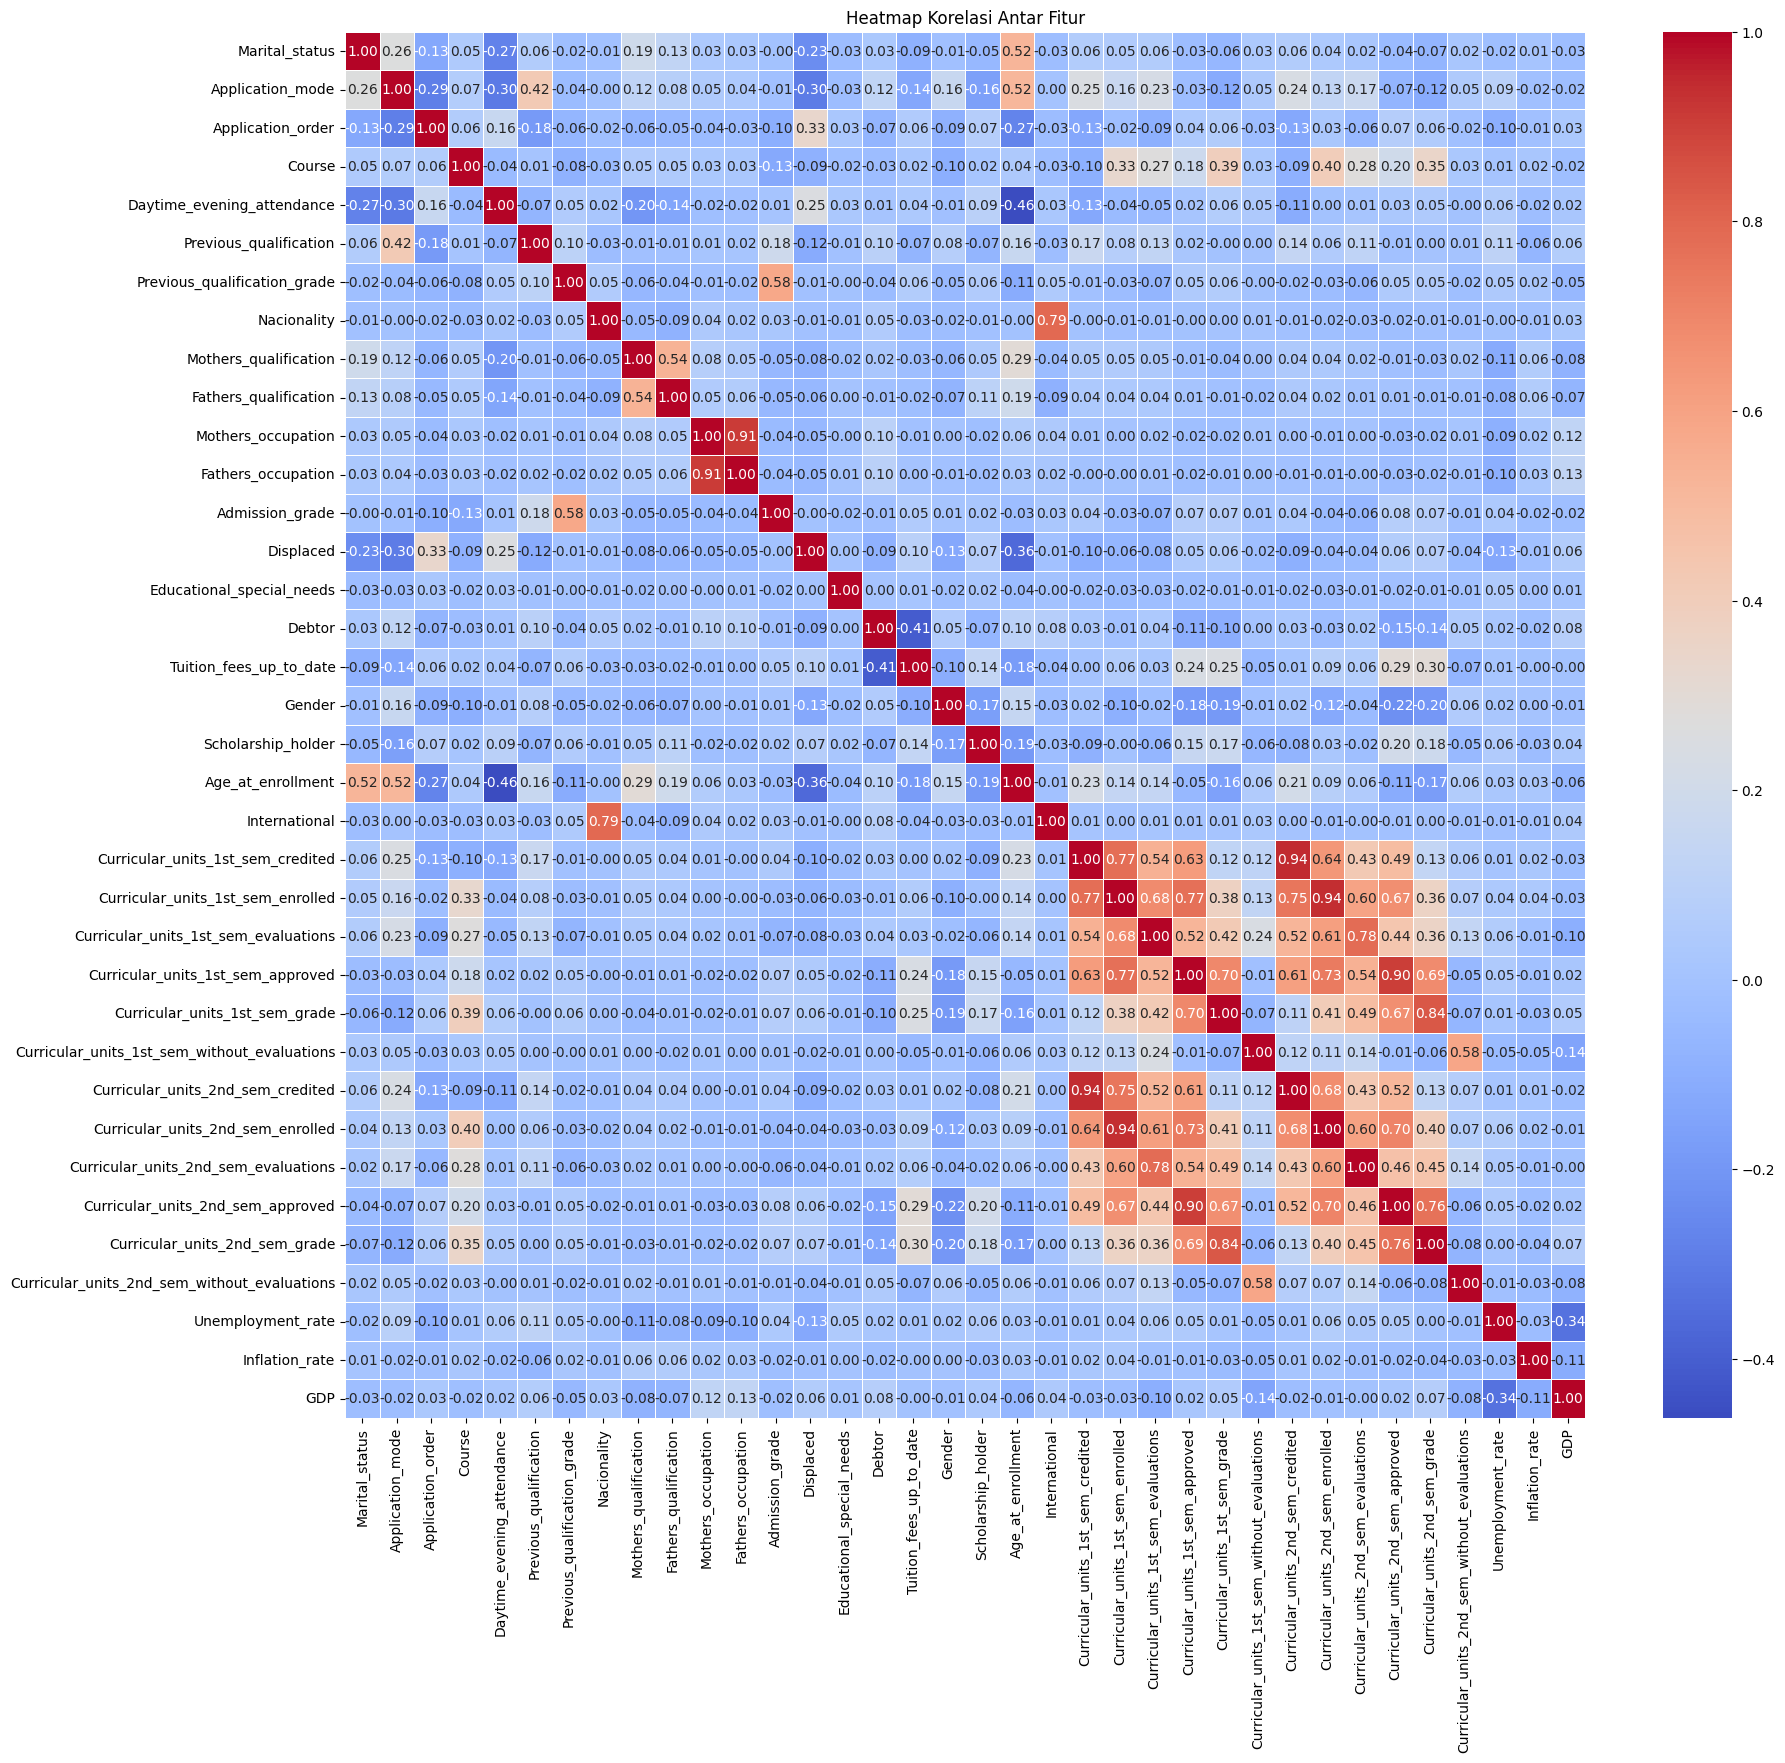

In [8]:
# Menampilkan korelasi antar fitur
# Ambil kolom numerik
numeric_df = students_df.select_dtypes(include=['int64', 'float64'])

# Hitung korelasi
corr_matrix = numeric_df.corr()

# Plot heatmap
plt.figure(figsize=(20,18))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Heatmap Korelasi Antar Fitur")
plt.show()

Berdasarkan hasil heatmap korelasi, analisi sebagai berikut:
- Faktor akademik paling berkorelasi: Variabel seperti Curricular_units_approved, Curricular_units_enrolled, dan Curricular_units_grade (semester 1 & 2) memiliki korelasi yang tinggi. Ini menunjukkan bahwa performa akademik saling terkait dan menjadi indikator keberhasilan siswa.
- Tidak ada korelasi antara faktor demografi dan ekonomi: Variabel seperti Gender, Marital_Status, GDP, Inflation_rate memiliki korelasi sangat rendah.

## Data Preparation / Preprocessing

Pada tahap ini, saya melakukan pengecekkan data nilai-nilai yang hilang, duplikat, dan unique. Langkah ini penting untuk memastikan kualitas data yang akan dianalisis lebih lanjut.



In [9]:
# Mengecek missing value dataset
students_df.isnull().sum()

,0
Marital_status,0
Application_mode,0
Application_order,0
Course,0
Daytime_evening_attendance,0
Previous_qualification,0
Previous_qualification_grade,0
Nacionality,0
Mothers_qualification,0
Fathers_qualification,0


In [10]:
# Mengecek duplikasi dataset
students_df.duplicated().sum()

np.int64(0)

In [11]:
# Mengecek unique dataset
students_df.nunique()

,0
Marital_status,6
Application_mode,18
Application_order,8
Course,17
Daytime_evening_attendance,2
Previous_qualification,17
Previous_qualification_grade,101
Nacionality,21
Mothers_qualification,29
Fathers_qualification,34


Pada tahap selanjutnya ini, saya akan melakukan label decoding pada beberapa feature. Hal ini akan membantu dalam membuat visualisasi dan analisis data lebih lanjut. Dan disimpan ke bentuk CSV yang nantinya akan digunakan untuk membuat dashboard.

In [12]:
# Label Decoding
eda_df = students_df.copy()

# Marital Status
marital_map = {
    1: 'Single',
    2: 'Married',
    3: 'Widower',
    4: 'Divorced',
    5: 'Facto Union',
    6: 'Legally Separated'
}
eda_df['Marital_status'] = eda_df['Marital_status'].map(marital_map)

# Gender
gender_map = {
    0: 'Female',
    1: 'Male'
}
eda_df['Gender'] = eda_df['Gender'].map(gender_map)

# International
international_map = {
    0: 'No',
    1: 'Yes'
}
eda_df['International'] = eda_df['International'].map(international_map)

# Debtor
debtor_map = {
    0: 'No',
    1: 'Yes'
}
eda_df['Debtor'] = eda_df['Debtor'].map(debtor_map)

# Scholarship
scholarship_map = {
    0: 'No',
    1: 'Yes'
}
eda_df['Scholarship_holder'] = eda_df['Scholarship_holder'].map(scholarship_map)

# Daytime / Evening
attendance_map = {
    0: 'Evening',
    1: 'Daytime'
}
eda_df['Daytime_evening_attendance'] = eda_df['Daytime_evening_attendance'].map(attendance_map)

# Course
course_map = {
    33: 'Biofuel Production Technologies',
    171: 'Animation and Multimedia Design',
    8014: 'Social Service (Evening)',
    9003: 'Agronomy',
    9070: 'Communication Design',
    9085: 'Veterinary Nursing',
    9119: 'Informatics Engineering',
    9130: 'Equinculture',
    9147: 'Management',
    9238: 'Social Service',
    9254: 'Tourism',
    9500: 'Nursing',
    9556: 'Oral Hygiene',
    9670: 'Advertising and Marketing Management',
    9773: 'Journalism and Communication',
    9853: 'Basic Education',
    9991: 'Management (Evening)'
}
eda_df['Course'] = eda_df['Course'].map(course_map)

eda_df

,Marital_status,Application_mode,Application_order,Course,Daytime_evening_attendance,Previous_qualification,Previous_qualification_grade,Nacionality,Mothers_qualification,Fathers_qualification,...,Curricular_units_2nd_sem_credited,Curricular_units_2nd_sem_enrolled,Curricular_units_2nd_sem_evaluations,Curricular_units_2nd_sem_approved,Curricular_units_2nd_sem_grade,Curricular_units_2nd_sem_without_evaluations,Unemployment_rate,Inflation_rate,GDP,Status
0,Single,17,5,Animation and Multimedia Design,Daytime,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,Single,15,1,Tourism,Daytime,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,Single,1,5,Communication Design,Daytime,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,Single,17,2,Journalism and Communication,Daytime,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,Married,39,1,Social Service (Evening),Evening,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4419,Single,1,6,Journalism and Communication,Daytime,1,125.0,1,1,1,...,0,6,8,5,12.666667,0,15.5,2.8,-4.06,Graduate
4420,Single,1,2,Journalism and Communication,Daytime,1,120.0,105,1,1,...,0,6,6,2,11.000000,0,11.1,0.6,2.02,Dropout
4421,Single,1,1,Nursing,Daytime,1,154.0,1,37,37,...,0,8,9,1,13.500000,0,13.9,-0.3,0.79,Dropout
4422,Single,1,1,Management,Daytime,1,180.0,1,37,37,...,0,5,6,5,12.000000,0,9.4,-0.8,-3.12,Graduate


In [13]:
# Save ke CSV baru
eda_df.to_csv('students_dataset.csv', index=False)

print("Data berhasil disimpan")

Data berhasil disimpan


Kedua fungsi berikut ini, akan digunakan untuk menampilkan visualisasi data dalam bentuk pie chart dan bar chart.

In [14]:
# Fungsi visualisais pie chart
def plot_pie(df, column, title):
  counts = df[column].value_counts()

  plt.figure(figsize=(6,6))
  plt.pie(
      counts,
      labels=counts.index,
      autopct='%1.1f%%',
      startangle=90
  )

  plt.title(title)
  plt.tight_layout()
  plt.show()

In [15]:
# Fungsi visualisasi bar chart
def plot_bar(df, kolom, hue=None, judul='Data', figsize=(8, 8)):
    plt.figure(figsize=figsize)

    ax = sns.countplot(
        data=df,
        y=kolom,
        hue=hue,
        order=df[kolom].value_counts().index
    )

    plt.title(f'Distribusi {judul}')
    plt.xlabel('Jumlah')
    plt.ylabel(kolom)
    plt.grid(axis='x', linestyle='--', alpha=0.7)

    if hue:
        plt.legend(title=hue, loc='lower right')

    for bar in ax.patches:
        width = bar.get_width()
        if width > 0:
            ax.annotate(
                f'{int(width)}',
                (width, bar.get_y() + bar.get_height() / 2),
                ha='left',
                va='center',
                xytext=(5, 0),
                textcoords='offset points'
            )

    plt.tight_layout()
    plt.show()

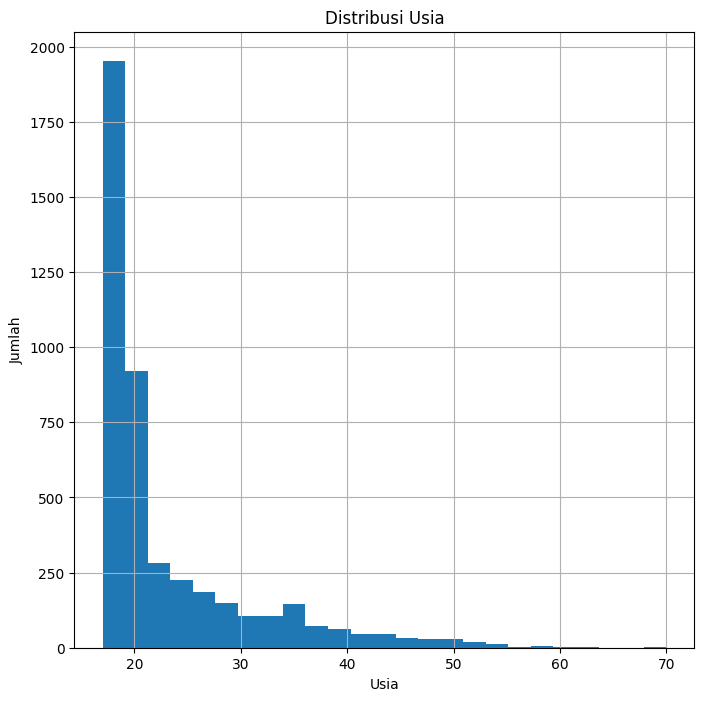

In [16]:
# Visualisasi melihat distribusi usia siswa
plt.figure(figsize=(8, 8))
plt.hist(eda_df['Age_at_enrollment'], bins=25)
plt.title('Distribusi Usia')
plt.xlabel('Usia')
plt.ylabel('Jumlah')
plt.grid()
plt.show()

Dari grafik distribusi usia diatas, diketahui bahwa frekuensi usia siswa paling banyak di usia 17-20 tahun.

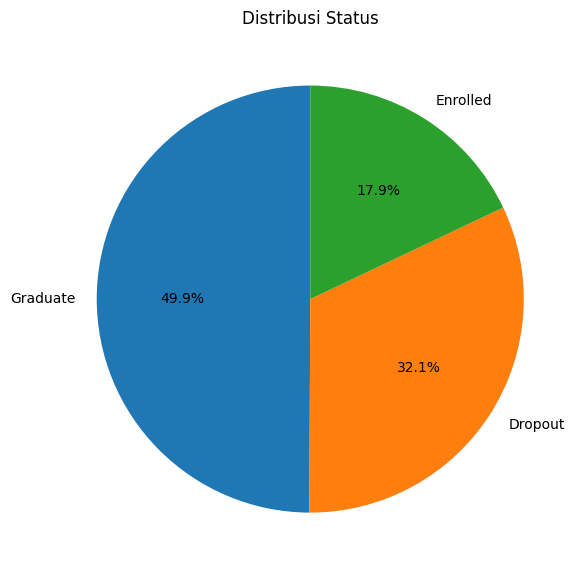

In [17]:
# Visualisasi distribusi status siswa
plot_pie(eda_df, 'Status', 'Distribusi Status')

Grafik diatas berikut menunjukkan pie chart distribusi status siswa. Terlihat bahwa siswa dengan status graduate sebesar 49.9%, kemudian status dropout sebesar 32.1%, dan enrolled status memiliki persentase paling kecil, 17.9%.

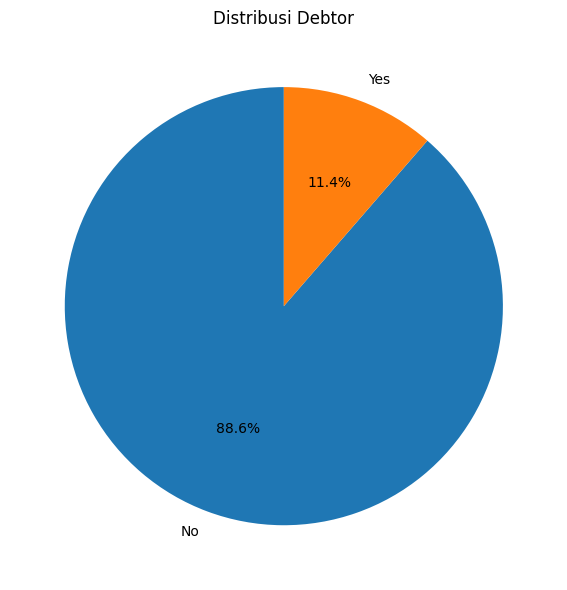

In [18]:
# Visualisasi distribusi debtor
plot_pie(eda_df, 'Debtor', 'Distribusi Debtor')

Pada grafik diatas siswa sebanyak 11.4% yang memiliki debtor, sedangkan 88.6% tidak.

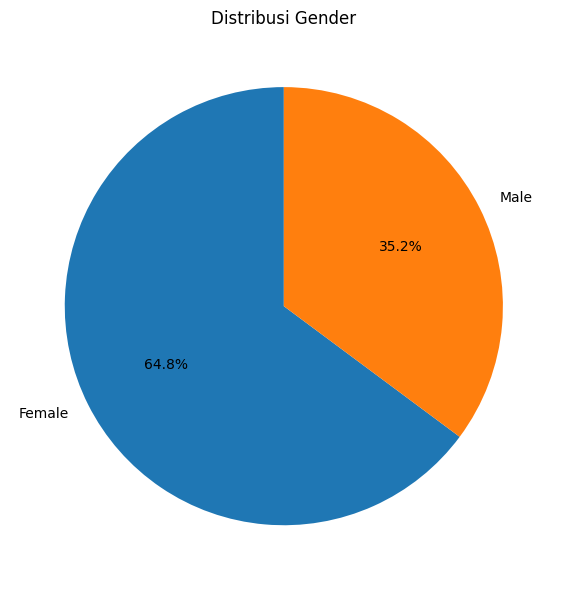

In [19]:
# Visualisasi distribusi gender
plot_pie(eda_df, 'Gender', 'Distribusi Gender')

Pada grafik diatas siswa perempuan sebanyak 64.8% dan laki-laki 35.2%.

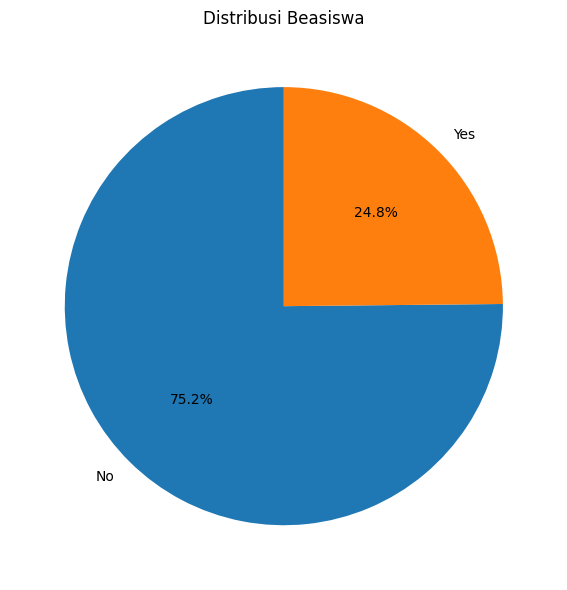

In [20]:
# Visualisasi distribusi scholarship
plot_pie(eda_df, 'Scholarship_holder', 'Distribusi Beasiswa')

Sebanyak 24.8% siswa menerima beasiswa, dan 75.2% tidak.

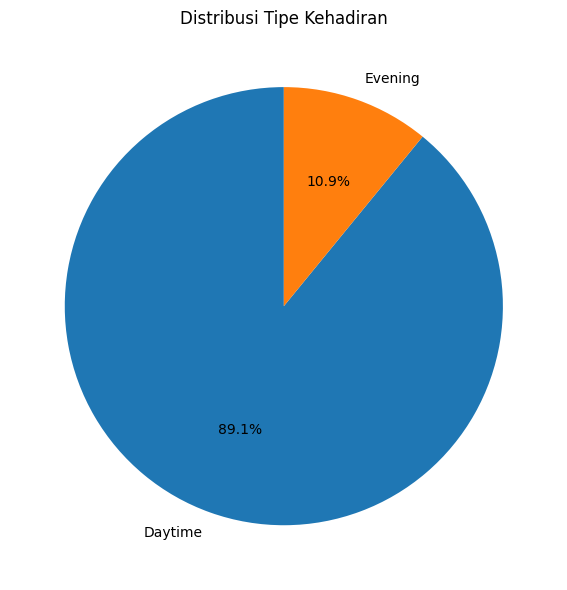

In [21]:
# Visualisasi distribusi attendance type
plot_pie(eda_df, 'Daytime_evening_attendance', 'Distribusi Tipe Kehadiran')

Siswa dengan kehadiran di siang hari (daytime) memiliki presentase tertinggi, sebesar 89.1%, sedangkan siswa dengan kehadiran di sore hari (evening) hanya 10.9%.

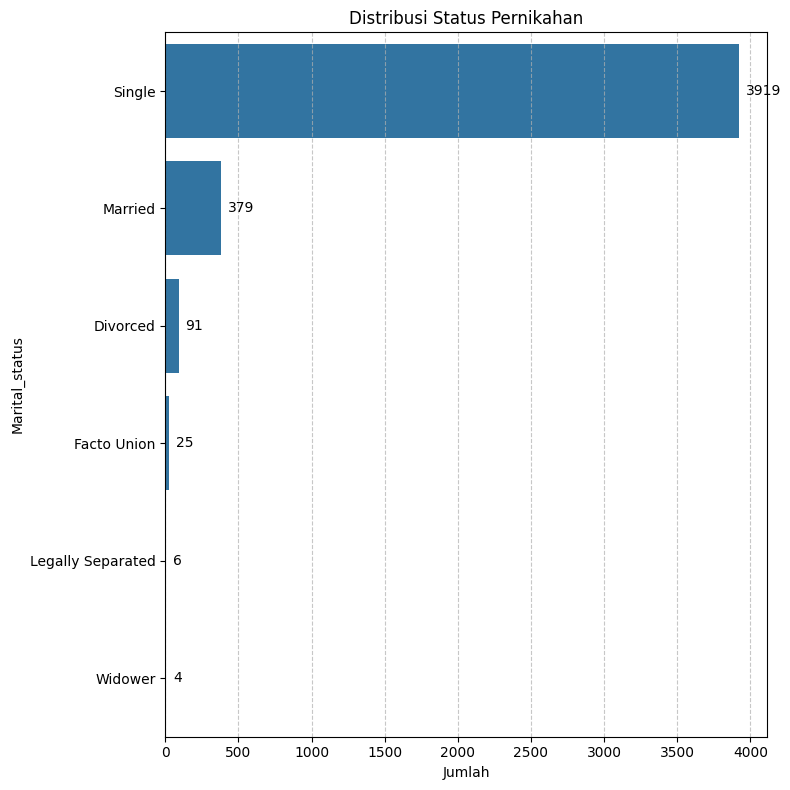

In [22]:
# Visualisasi distribusi marital status
plot_bar(eda_df, 'Marital_status', judul='Status Pernikahan')

Dari grafik diatas kebanyak siswa memiliki marital status single.

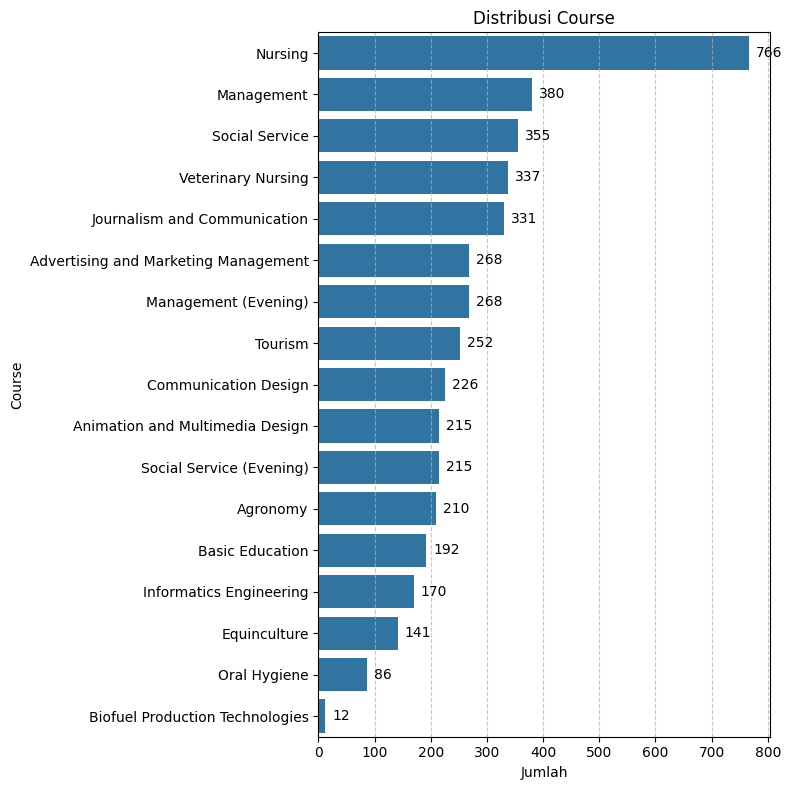

In [23]:
# Visualisasi distribusi course
plot_bar(eda_df, 'Course', judul='Course')

Course paling banyak terdapat pada Nursing, hingga course yang paling sedikit, yaitu Biofuel Production Technologies.

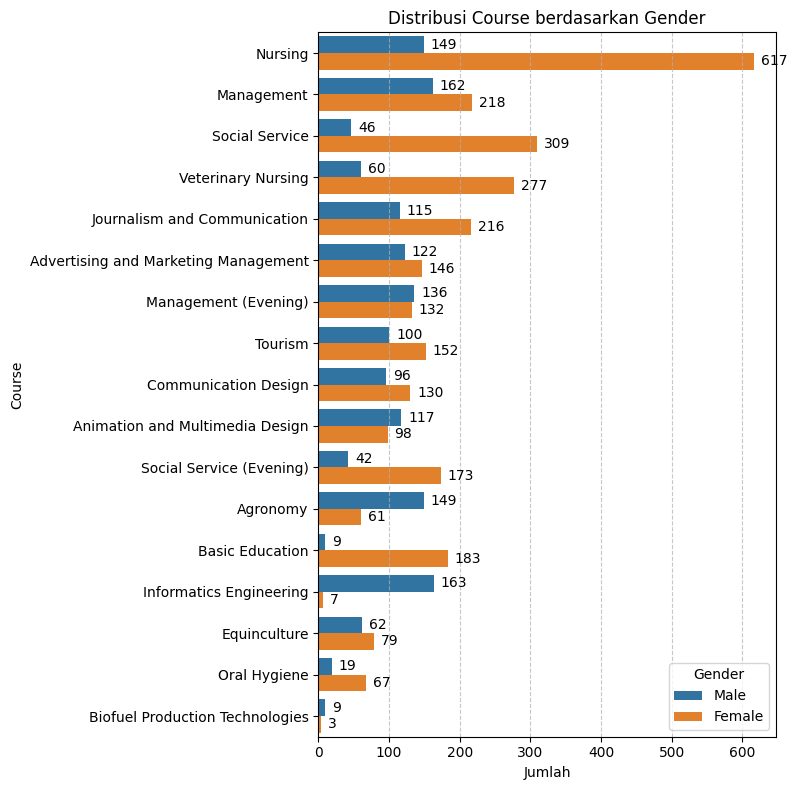

In [24]:
# Visualisasi distribusi course berdasarkan gender
plot_bar(eda_df, 'Course', hue='Gender', judul='Course berdasarkan Gender')

Course dengan data terbanyak adalah Nursing dengan jenis kelamin dominan perempuan dibandingkan laki-laki. Sedangkan Course dengan data paling sedikit adalah Biofuel Production Technologies dengan didominasi laki-laki.

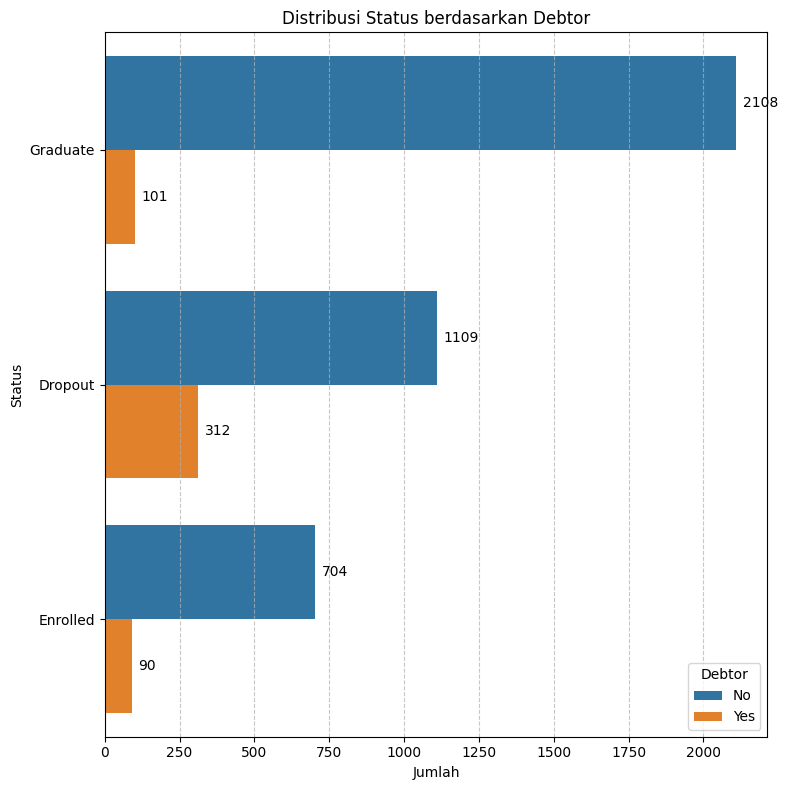

In [25]:
# Visualisasi distribusi status berdasarkan debtor
plot_bar(eda_df, 'Status', hue='Debtor', judul='Status berdasarkan Debtor')

Siswa dengan debtor terlihat jelas termasuk dalam kelompok yang paling banyak dropout. Hal ini menunjukkan faktor finansial menjadi salah satu faktor yang mempengaruhi tingkat graduate dan dropout siswa.

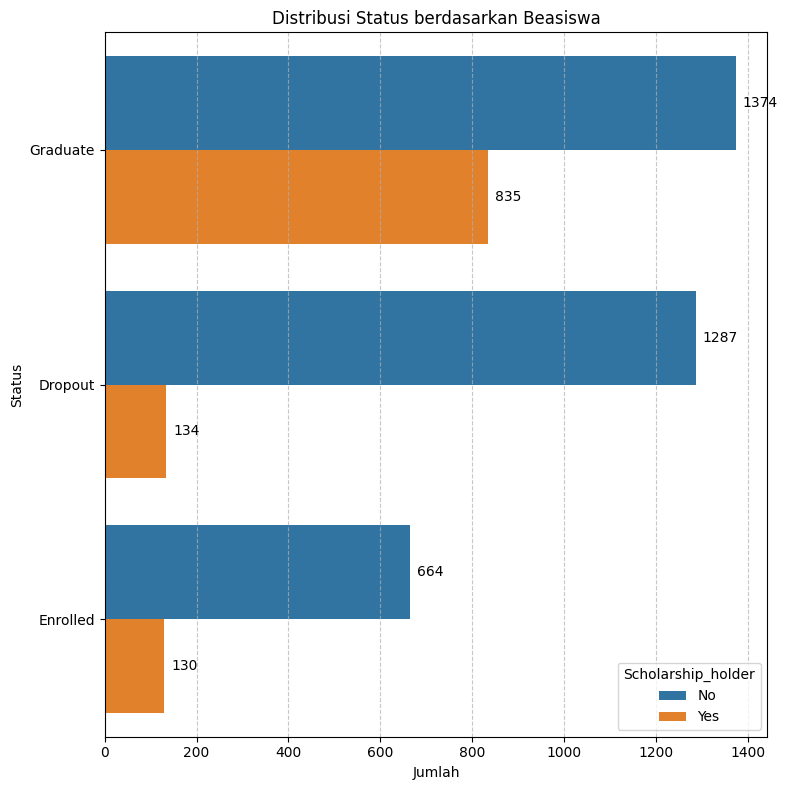

In [26]:
# Visualisasi distribusi status berdasarkan scholarship
plot_bar(eda_df, 'Status', hue='Scholarship_holder', judul='Status berdasarkan Beasiswa')

Dari grafik terlihat bahwa jumlah siswa penerima beasiswa yang telah lulus lebih banyak daripada mahasiswa yang dropout. Jumlah siswa penerima beasiswa yang dropout dan enrolled hampir sama dan tidak jauh berbeda.

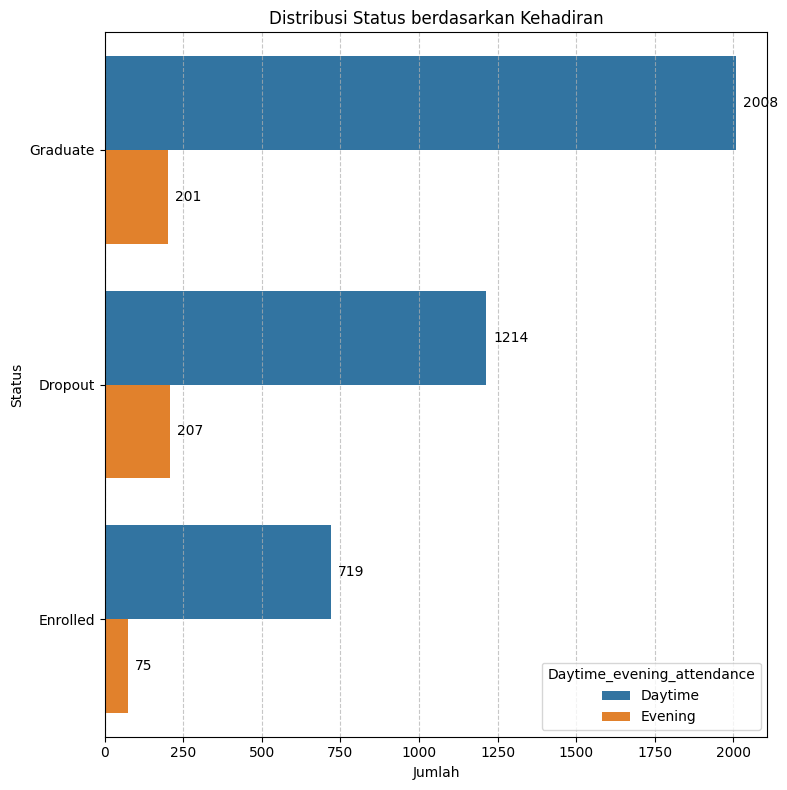

In [27]:
# Visualisasi distribusi status siswa berdasarkan kehadiran
plot_bar(eda_df, 'Status', hue='Daytime_evening_attendance', judul='Status berdasarkan Kehadiran')

Jumlah siswa dropout yang kehadirannya di sore hari (evening) berbeda tipis lebih banyak dengan siswa yang datang di pagi hari (daytime). Hal ini menunjukkan faktor kehadiran di evening menjadi salah satu faktor pengaruh siswa dropout.

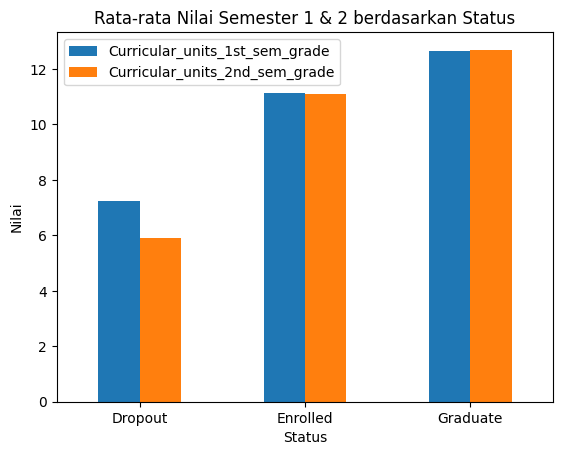

In [28]:
# Visualisasi performa akademik siswa semeter 1 dan 2
eda_df.groupby('Status')[[
    'Curricular_units_1st_sem_grade',
    'Curricular_units_2nd_sem_grade'
]].mean().plot(kind='bar')

plt.title('Rata-rata Nilai Semester 1 & 2 berdasarkan Status')
plt.ylabel('Nilai')
plt.xticks(rotation=0)
plt.show()

Performa akademik siswa di semester awal menjadi penentu, terlihat jelas bahwa rata-rata nilai semester 1 dan 2 pada kelompok dropout jauh lebih rendah dibandingkan kelompok lainnya.

Label Encoding

Pada tahap ini, setelah memahami lebih lanjut terkait data, selanjutnya akan dilakukan tahap label encoding hingga splitting data untuk melatih model.

In [29]:
# Label encoding fitur categorical (object)
le = LabelEncoder()

students_df['Status'] = le.fit_transform(students_df['Status'])

# cek mapping
mapp = dict(zip(le.classes_, le.transform(le.classes_)))
mapp

{'Dropout': np.int64(0), 'Enrolled': np.int64(1), 'Graduate': np.int64(2)}

In [30]:
# Mengambil data hanya dengan status dropout dan graduate
le_df = students_df[students_df['Status'] != 1]
le_df = le_df.reset_index(drop=True)

le_df.loc[:, 'Status'] = le_df['Status'].replace({2: 1})
le_df

,Marital_status,Application_mode,Application_order,Course,Daytime_evening_attendance,Previous_qualification,Previous_qualification_grade,Nacionality,Mothers_qualification,Fathers_qualification,...,Curricular_units_2nd_sem_credited,Curricular_units_2nd_sem_enrolled,Curricular_units_2nd_sem_evaluations,Curricular_units_2nd_sem_approved,Curricular_units_2nd_sem_grade,Curricular_units_2nd_sem_without_evaluations,Unemployment_rate,Inflation_rate,GDP,Status
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,0
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,1
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,0
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,1
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3625,1,1,6,9773,1,1,125.0,1,1,1,...,0,6,8,5,12.666667,0,15.5,2.8,-4.06,1
3626,1,1,2,9773,1,1,120.0,105,1,1,...,0,6,6,2,11.000000,0,11.1,0.6,2.02,0
3627,1,1,1,9500,1,1,154.0,1,37,37,...,0,8,9,1,13.500000,0,13.9,-0.3,0.79,0
3628,1,1,1,9147,1,1,180.0,1,37,37,...,0,5,6,5,12.000000,0,9.4,-0.8,-3.12,1


In [31]:
# Mengecek jumlah perstatus
le_df['Status'].value_counts()

,count
Status,
1,2209
0,1421


Feature Selection

In [32]:
# Memfilter semua fitur data yang memiliki korelasi absolut kurang dari 0,1
filtered_df = le_df.loc[:, le_df.corr()['Status'].abs().ge(0.1)]
filtered_df

,Marital_status,Application_mode,Previous_qualification_grade,Admission_grade,Displaced,Debtor,Tuition_fees_up_to_date,Gender,Scholarship_holder,Age_at_enrollment,Curricular_units_1st_sem_enrolled,Curricular_units_1st_sem_approved,Curricular_units_1st_sem_grade,Curricular_units_2nd_sem_enrolled,Curricular_units_2nd_sem_evaluations,Curricular_units_2nd_sem_approved,Curricular_units_2nd_sem_grade,Curricular_units_2nd_sem_without_evaluations,Status
0,1,17,122.0,127.3,1,0,1,1,0,20,0,0,0.000000,0,0,0,0.000000,0,0
1,1,15,160.0,142.5,1,0,0,1,0,19,6,6,14.000000,6,6,6,13.666667,0,1
2,1,1,122.0,124.8,1,0,0,1,0,19,6,0,0.000000,6,0,0,0.000000,0,0
3,1,17,122.0,119.6,1,0,1,0,0,20,6,6,13.428571,6,10,5,12.400000,0,1
4,2,39,100.0,141.5,0,0,1,0,0,45,6,5,12.333333,6,6,6,13.000000,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3625,1,1,125.0,122.2,0,0,1,1,0,19,6,5,13.600000,6,8,5,12.666667,0,1
3626,1,1,120.0,119.0,1,1,0,0,0,18,6,6,12.000000,6,6,2,11.000000,0,0
3627,1,1,154.0,149.5,1,0,1,0,1,30,7,7,14.912500,8,9,1,13.500000,0,0
3628,1,1,180.0,153.8,1,0,1,0,1,20,5,5,13.800000,5,6,5,12.000000,0,1


In [33]:
# Menampilkan statistik deskriptif
filtered_df.describe()

,Marital_status,Application_mode,Previous_qualification_grade,Admission_grade,Displaced,Debtor,Tuition_fees_up_to_date,Gender,Scholarship_holder,Age_at_enrollment,Curricular_units_1st_sem_enrolled,Curricular_units_1st_sem_approved,Curricular_units_1st_sem_grade,Curricular_units_2nd_sem_enrolled,Curricular_units_2nd_sem_evaluations,Curricular_units_2nd_sem_approved,Curricular_units_2nd_sem_grade,Curricular_units_2nd_sem_without_evaluations,Status
count,3630.000000,3630.000000,3630.000000,3630.000000,3630.000000,3630.000000,3630.000000,3630.000000,3630.000000,3630.000000,3630.000000,3630.000000,3630.000000,3630.000000,3630.000000,3630.000000,3630.000000,3630.000000,3630.000000
mean,1.184298,18.421763,132.920606,127.293939,0.549036,0.113774,0.866116,0.344077,0.266942,23.461157,6.337466,4.791460,10.534860,6.296419,7.763085,4.518457,10.036155,0.142149,0.608540
std,0.613009,17.358595,13.238373,14.611295,0.497658,0.317580,0.340575,0.475132,0.442423,7.827994,2.570773,3.237845,5.057694,2.263020,3.964163,3.162376,5.481742,0.747670,0.488144
min,1.000000,1.000000,95.000000,95.000000,0.000000,0.000000,0.000000,0.000000,0.000000,17.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.000000,1.000000,125.000000,118.000000,0.000000,0.000000,1.000000,0.000000,0.000000,19.000000,5.000000,3.000000,11.000000,5.000000,6.000000,2.000000,10.517857,0.000000,0.000000
50%,1.000000,17.000000,133.100000,126.500000,1.000000,0.000000,1.000000,0.000000,0.000000,20.000000,6.000000,5.000000,12.341429,6.000000,8.000000,5.000000,12.333333,0.000000,1.000000
75%,1.000000,39.000000,140.000000,135.100000,1.000000,0.000000,1.000000,1.000000,1.000000,25.000000,7.000000,6.000000,13.500000,7.000000,10.000000,6.000000,13.500000,0.000000,1.000000
max,6.000000,57.000000,190.000000,190.000000,1.000000,1.000000,1.000000,1.000000,1.000000,70.000000,26.000000,26.000000,18.875000,23.000000,33.000000,20.000000,18.571429,12.000000,1.000000


Data Splitting

In [34]:
# Splitting dataset dengan 80% data train dan 20% data test
X = filtered_df.drop('Status', axis=1)
y = filtered_df['Status']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train:", X_train.shape)
print("Test:", X_test.shape)

Train: (2904, 18)
Test: (726, 18)


Standardization Data

In [35]:
# Melakukan standarisasi
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Modeling

Pada tahapan ini, akan dilakukan percobaan pelatihan beberapa model Machine Learning untuk menemukan best model.

In [36]:
# Model klasifikasi
models = {
    'Logistic Regression': LogisticRegression(class_weight='balanced'),
    'SVM': SVC(class_weight='balanced', probability=True),
    'Decision Tree': DecisionTreeClassifier(class_weight='balanced', random_state=42),
    'Random Forest': RandomForestClassifier(class_weight='balanced', random_state=42)
}

results = []

for name, model in models.items():

    if name in ['Logistic Regression', 'SVM']:
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

    results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1-Score': f1_score(y_test, y_pred)
    })

results_df = pd.DataFrame(results).sort_values(by='F1-Score', ascending=False)
results_df

,Model,Accuracy,Precision,Recall,F1-Score
3,Random Forest,0.910468,0.888660,0.975113,0.929881
0,Logistic Regression,0.913223,0.918322,0.941176,0.929609
1,SVM,0.904959,0.899358,0.950226,0.924092
2,Decision Tree,0.853994,0.878378,0.882353,0.880361


Dari hasil matriks beberapa model diatas, model Random Forest paling mengungguli dari model lainnya, sehingga model ini yang akan digunakan untuk memprediksi siswa dropout.

In [37]:
# Model Random Forest
model_rf = RandomForestClassifier(class_weight='balanced', random_state=42). fit(X_train, y_train)
model_rf

RandomForestClassifier(class_weight='balanced', random_state=42)

In [38]:
# Melatih model
y_train_rf = model_rf.predict(X_train)
y_test_rf = model_rf.predict(X_test)

## Evaluation

Pada tahap ini, dilakukan evaluasi  awal untuk base model Random forest, dan melihat apakah perlu dilakukan hyperparameter tuning.

In [39]:
# Fungsi untuk menampilkan classification report dan confusion matrix
def evaluation_report(y_true, y_pred, title='Data'):
  print('Classification Report on ' + title)
  print(classification_report(y_true, y_pred))

  plt.figure(figsize=(6, 6))
  sns.heatmap(confusion_matrix(y_true, y_pred), annot=True, fmt='d', cmap='Blues')
  plt.title('Confusion Matrix on ' + title)
  plt.ylabel('True Label', fontsize=10)
  plt.xlabel('Predict Label', fontsize=10)
  plt.show()

Classification Report on Train Data
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1137
           1       1.00      1.00      1.00      1767

    accuracy                           1.00      2904
   macro avg       1.00      1.00      1.00      2904
weighted avg       1.00      1.00      1.00      2904



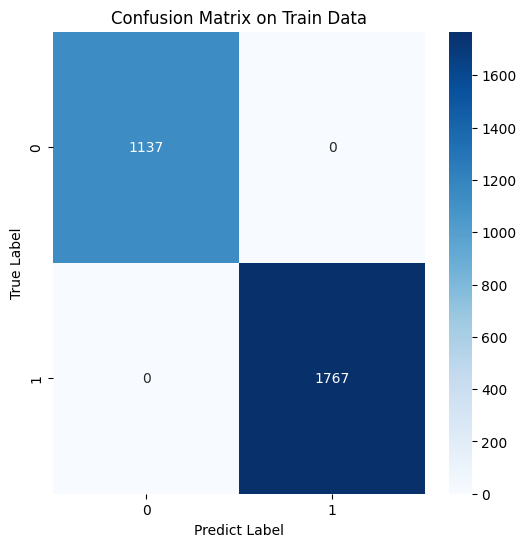

In [40]:
# Hasil matrix evaluasi train model
evaluation_report(y_train, y_train_rf, title='Train Data')

Classification Report on Testing Data
              precision    recall  f1-score   support

           0       0.95      0.81      0.88       284
           1       0.89      0.98      0.93       442

    accuracy                           0.91       726
   macro avg       0.92      0.89      0.90       726
weighted avg       0.91      0.91      0.91       726



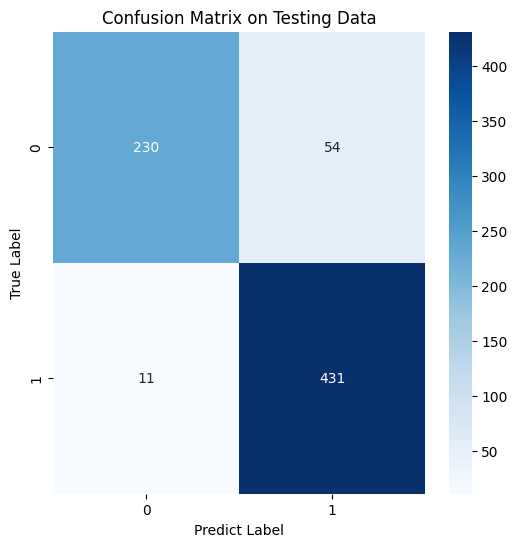

In [41]:
# Hasil matrix evaluasi test model
evaluation_report(y_test, y_test_rf, title='Testing Data')

Pada tahap selanjutnya dilakukan hyperparamter untuk model Random Forest menggunakan Grid Search untuk memperoleh akurasi terbaik.

In [42]:
# Hyperparameter tuning model menggunakan Grid Search Cross Validation
param_grid = {
    'n_estimators': [100, 200],
    'criterion': ['gini', 'entropy'],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'max_features': ['sqrt', 'log2']
}

grid_search = GridSearchCV(estimator=model_rf, param_grid=param_grid, scoring='f1', cv=5, n_jobs=-1, verbose=2)
grid_search

GridSearchCV(cv=5,
             estimator=RandomForestClassifier(class_weight='balanced',
                                              random_state=42),
             n_jobs=-1,
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': [None, 10, 20],
                         'max_features': ['sqrt', 'log2'],
                         'min_samples_leaf': [1, 2],
                         'min_samples_split': [2, 5],
                         'n_estimators': [100, 200]},
             scoring='f1', verbose=2)

In [43]:
# Fit best model params estimators
grid_search.fit(X_train, y_train)

best_rf = grid_search.best_estimator_

y_train_best = best_rf.predict(X_train)
y_test_best = best_rf.predict(X_test)

Fitting 5 folds for each of 96 candidates, totalling 480 fits


Classification Report on Train Data Best Model
              precision    recall  f1-score   support

           0       0.98      0.95      0.97      1137
           1       0.97      0.99      0.98      1767

    accuracy                           0.97      2904
   macro avg       0.98      0.97      0.97      2904
weighted avg       0.97      0.97      0.97      2904



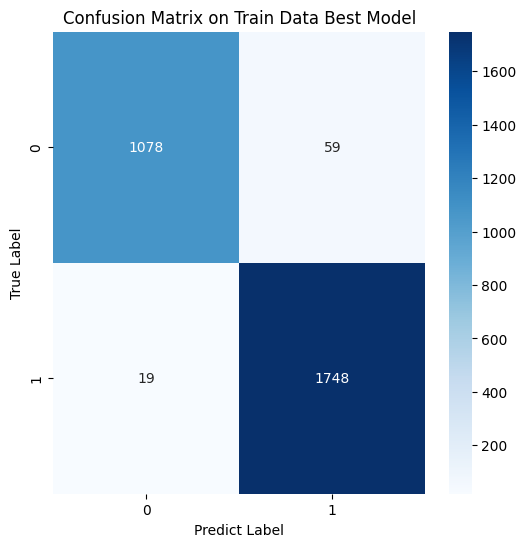

In [44]:
# Hasil matrix evaluasi train model
evaluation_report(y_train, y_train_best, title='Train Data Best Model')

Classification Report on Test Data Best Model
              precision    recall  f1-score   support

           0       0.94      0.82      0.88       284
           1       0.90      0.97      0.93       442

    accuracy                           0.91       726
   macro avg       0.92      0.90      0.90       726
weighted avg       0.91      0.91      0.91       726



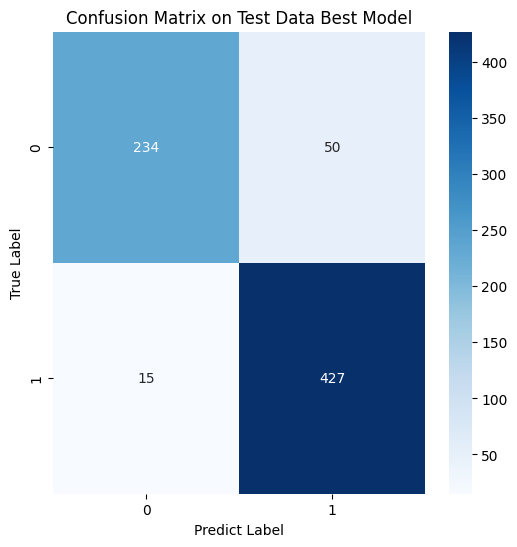

In [45]:
# Hasil matrix evaluasi test model
evaluation_report(y_test, y_test_best, title='Test Data Best Model')

Model Random Forest sebelum tuning menunjukkan indikasi overfitting dengan data training mencapai 1.00, sedangkan performa pada data testing berada di sekitar 0.91.

Setelah dilakukan hyperparameter tuning, performa pada data training menurun menjadi 0.97, namun performa pada data testing tetap stabil.

Hal ini menunjukkan bahwa model hasil tuning lebih stabil dan memiliki kemampuan generalisasi yang lebih baik. Model hasil tuning akan dipilih sebagai best model dan disimpan dalam bentuk h5.

In [46]:
# Menyimpan Model
joblib.dump(best_rf, 'random_forest_model.pkl')

['random_forest_model.pkl']